In [3]:
from langgraph.graph import StateGraph,START,END
from typing import TypedDict
import math
from langchain_groq import ChatGroq
from langchain_ollama import ChatOllama
from dotenv import load_dotenv

In [4]:
llm_groq=ChatGroq(
    model="llama-3.3-70b-versatile",
    temperature=0.8
)
llm_ollama=ChatOllama(
    model="phi3:mini",
    temperature=0.9
)

In [5]:
class QAState(TypedDict):
    question:str
    answer:str
    llm:str
    selected_llm:object

In [6]:
def choose_llm(state:QAState)->QAState:
    sel_llm=state["llm"]
    if sel_llm=="llm_groq":
        state["selected_llm"]=llm_groq
    elif sel_llm=="llm_ollama":
        state["selected_llm"]=llm_ollama  
    return state


In [7]:
def llm_response(state:QAState)->QAState:
    llm=state["selected_llm"]
    question=state["question"]
    prompt=f"answer the following :{question} in a short beautiful framming manner"
    response=llm.invoke(prompt)
    state["answer"]=response.content
    return state

In [8]:
graph=StateGraph(QAState)
graph.add_node("ask_llm",llm_response)
graph.add_node("select_llm",choose_llm)

graph.add_edge(START,"select_llm")
graph.add_edge("select_llm","ask_llm")
graph.add_edge("ask_llm",END)

workflow=graph.compile()

In [9]:
initial_state={"question":"what is the capital of india","llm":"llm_ollama"}
output_state=workflow.invoke(initial_state)

In [10]:
output_state

{'question': 'what is the capital of india',
 'answer': "At India's heart, where dreams are born and history unfolds, there lies New Delhi – a city with stories etched on every corner. This bustling metropolis stands as the cradle for governance while embracing its cultural richness in all of her glory; thus serving as our capital city since 1956 under Prime Minister Lal Bahadur Shastri and further refined by modern visionaries Jawaharlal Nehru, Indira Gandhi, Rajiv Gandhi, Sonia Gandhi and Narendra Modi. It is in New Delhi that the spirit of India shines brightest!",
 'llm': 'llm_ollama',
 'selected_llm': ChatOllama(model='phi3:mini', temperature=0.9)}

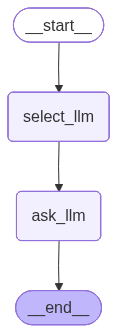

In [11]:
workflow